# Visualization Demo

This notebook is only to test and see the plots from `visualization.py`.

It uses one example guide/target pair and fake attention values, like what the model would return after prediction.


In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visualization import (
    risk_level,
    get_top_positions,
    plot_risk_score,
    plot_attention_by_position,
    plot_sequence_highlight,
    plot_batch_risk_summary,
    make_visual_report,
)

print("Visualization functions imported")


Visualization functions imported


# Example Prediction Data

This simulates the output of the model.

In the real website, these values will come from the prediction function.


In [2]:
# ============================================================
# 2. EXAMPLE DATA
# ============================================================

guide = "GAGTCCGAGCAGAAGAAGAAGGG"
target = "GAGTCCGAGCAGAAGAAGAAGGA"

probability = 0.82

attention = np.array([
    0.02, 0.02, 0.03, 0.02, 0.03, 0.02, 0.03, 0.04,
    0.03, 0.04, 0.04, 0.05, 0.04, 0.05, 0.04, 0.05,
    0.06, 0.05, 0.08, 0.09, 0.08, 0.06, 0.04
])

print("Risk level:", risk_level(probability))
print("Top important positions:", get_top_positions(attention))


Risk level: High
Top important positions: [20, 19, 21]


# Plot 1 - Risk Score

This plot shows the predicted off-target risk.


# Plot 2 - Important Positions

This plot shows which sequence positions are most important according to attention.

The red bars are the top positions.


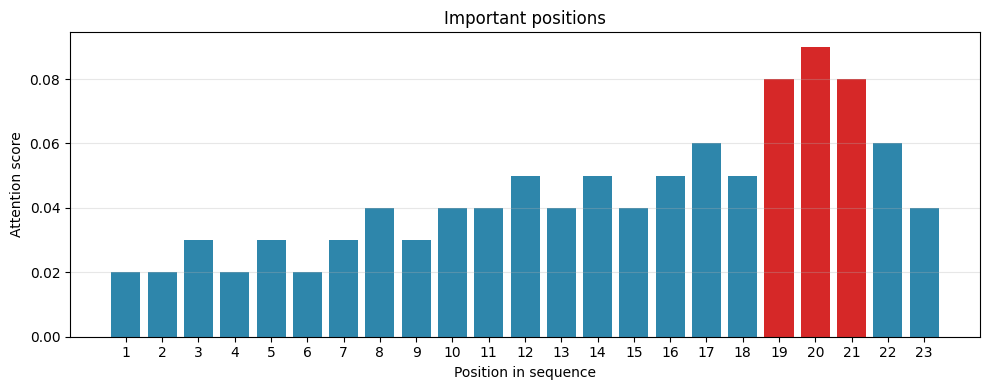

In [4]:
# ============================================================
# 4. ATTENTION BY POSITION PLOT
# ============================================================

fig = plot_attention_by_position(attention)
plt.show()


# Plot 3 - Highlighted Sequence

This plot shows the guide and target sequence.

The highlighted positions are the most important positions found by XAI.


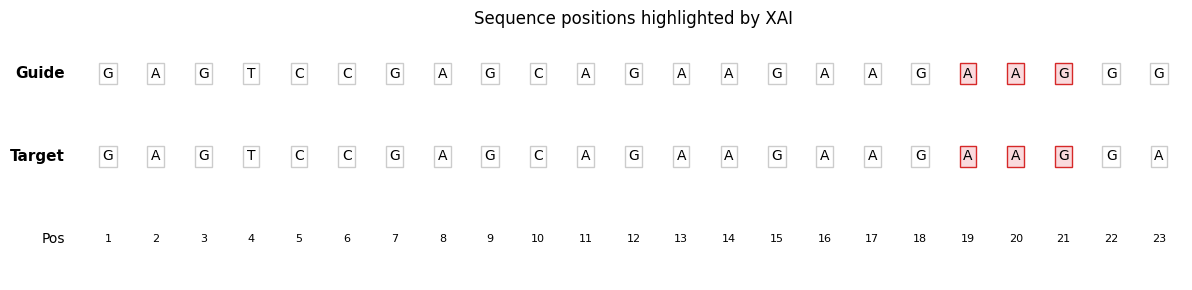

In [5]:
# ============================================================
# 5. SEQUENCE HIGHLIGHT PLOT
# ============================================================

fig = plot_sequence_highlight(guide, target, attention)
plt.show()


# Plot 4 - Batch Risk Summary

This plot is useful when the user uploads many sequence pairs.

It shows the risk score for each pair.


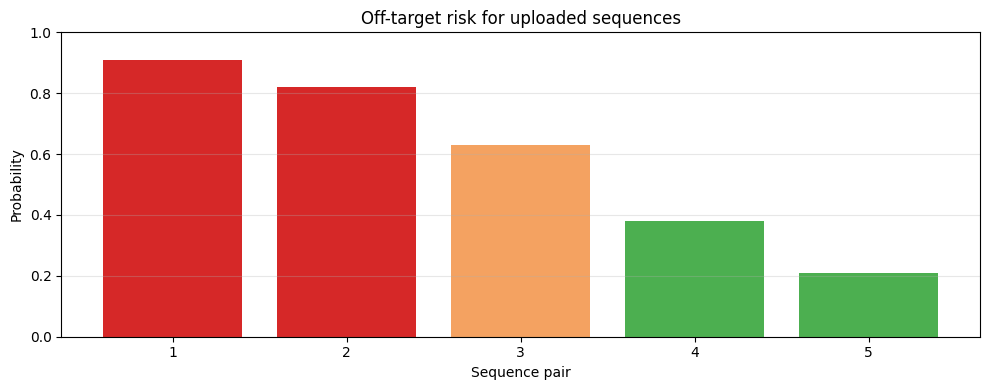

In [6]:
# ============================================================
# 6. BATCH RISK SUMMARY PLOT
# ============================================================

batch_results = [
    {"guide": "seq1", "target": "target1", "probability": 0.82},
    {"guide": "seq2", "target": "target2", "probability": 0.63},
    {"guide": "seq3", "target": "target3", "probability": 0.21},
    {"guide": "seq4", "target": "target4", "probability": 0.91},
    {"guide": "seq5", "target": "target5", "probability": 0.38},
]

fig = plot_batch_risk_summary(batch_results)
plt.show()


# Full Visual Report

This function creates all main plots and saves them in the `figures` folder.


In [7]:
# ============================================================
# 7. FULL VISUAL REPORT
# ============================================================

report = make_visual_report(
    guide=guide,
    target=target,
    probability=probability,
    attention=attention,
    prefix="demo_prediction",
)

report


{'probability': 0.82,
 'risk_level': 'High',
 'important_positions': [20, 19, 21],
 'figures': {'risk_score': 'C:\\Users\\NZALI SYLLA\\Desktop\\X-CRISP-XAI\\backend\\XAI\\figures\\demo_prediction_risk_score.png',
  'attention_positions': 'C:\\Users\\NZALI SYLLA\\Desktop\\X-CRISP-XAI\\backend\\XAI\\figures\\demo_prediction_attention_positions.png',
  'sequence_highlight': 'C:\\Users\\NZALI SYLLA\\Desktop\\X-CRISP-XAI\\backend\\XAI\\figures\\demo_prediction_sequence_highlight.png'}}

# Conclusion

These are the main visualizations that can be used in the website:

- risk score
- important positions
- highlighted sequence
- batch summary for uploaded files

For live predictions, attention is fast and useful for visualization. SHAP is better for deeper analysis but can be slower.
